# Численное моделирование распространения сейсмических волн в двумерной среде MILEN SEM 2D. Часть первая.

## Глава VI: Генерация материала под новую структуру слоев

В главе I мы создали материал под старую структуру из 18 слоев. Теперь мы должны создать новый материал под новую структуру слоев.

### Задача 1 ###

Геометрия границ новой структуры слоев  хранится в data/dev_1_5_2_layer_boundaries_quadratic.npz 

Так же для работы нам потребуются /home/antonov/MilenSem2D/src/well1_Backus_Elast_Vp_Vs_rhob.txt и
/home/antonov/MilenSem2D/src/well_2_Backus_Elast_param_Vp_Vs_rhob.txt

Назовем систему координат x y , вмороженную в пространство, Эйлеровой а систему координат $\xi \psi$ вможенную в телу Лагранджевой. Мне нужно воссоздавать материал в лагранджевой, после чего перевести его в сетку на эйлеровой (тогда история геологических изменений слоев лучше в этом материале отразится). Внутри каждого слоя в координатах Лагранджа нужно создать мелкую структурированную сетку (высотой не более 10, шириной 50), после чего записать инфу о материале в ячейки этой сетки и создать отображение этой сетки в эйлерово пространство.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from pykrige.ok import OrdinaryKriging
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning)

#### 1. Загрузка данных ####

In [2]:
# Глобальный флаг для управления отображением графиков
SHOW_PLOTS = True # True - показывать графики, False - только сохранять

# Загрузка геометрии новых слоев
layer_data_path = Path('data/dev_1_5_2_layer_boundaries_quadratic.npz')
layer_data = np.load(layer_data_path)
layer_boundaries_array = layer_data['layer_boundaries_array']  # shape (75, 1176)
formations = layer_data['formations']
well1_depths_new = layer_data['well1_depths']
well2_depths_new = layer_data['well2_depths']
distances = layer_data['distances']  # shape (1176,)

print(f"Загружена геометрия слоев: {layer_boundaries_array.shape}")
print(f"Количество формаций: {len(formations)}")
max_depth = np.max(layer_boundaries_array)
print(f"Максимальная глубина новых слоев: {max_depth:.2f} м")

# Парсинг данных скважин (используем функцию из dev_1_1)

Загружена геометрия слоев: (75, 1176)
Количество формаций: 75
Максимальная глубина новых слоев: 2750.00 м


In [3]:
def parse_well_data(filepath):
    """
    Парсит файл с данными скважины и возвращает исправленные данные.
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()[1:]  # пропускаем заголовок

    data = []
    for line in lines:
        parts = line.split()
        if len(parts) >= 4:  # проверяем, что есть все 4 значения
            data.append([float(parts[1]), float(parts[2]), float(parts[3])])  # Vp, rhob, Vs

    data_array = np.array(data)
    num_points = len(data_array)

    # Создаем правильные глубины - шаг 10 м начиная с 10 м для всех точек
    corrected_depths = np.arange(10, 10 + num_points * 10, 10)

    # Извлекаем параметры
    vp = data_array[:, 0]    # Vp - скорость продольной волны
    rhob = data_array[:, 1]  # Плотность
    vs = data_array[:, 2]    # Vs - скорость поперечной волны

    return corrected_depths, vp, rhob, vs

In [4]:
well1_depth, well1_vp, well1_rhob, well1_vs = parse_well_data('src/well1_Backus_Elast_Vp_Vs_rhob.txt')
well2_depth, well2_vp, well2_rhob, well2_vs = parse_well_data('src/well_2_Backus_Elast_param_Vp_Vs_rhob.txt')

# Параметры модели
WELL1_DISTANCE = 4250  # м от начала профиля
WELL2_DISTANCE = 7500  # м от начала профиля
well1_idx = np.argmin(np.abs(distances - WELL1_DISTANCE))
well2_idx = np.argmin(np.abs(distances - WELL2_DISTANCE))

print(f"Скважина 1: {WELL1_DISTANCE} м (индекс {well1_idx})")
print(f"Скважина 2: {WELL2_DISTANCE} м (индекс {well2_idx})")

Скважина 1: 4250 м (индекс 425)
Скважина 2: 7500 м (индекс 750)


#### 2. Подготовка данных послойно ####

In [5]:
# Добавляем поверхность (глубина 0) в начало
all_boundaries = np.vstack([np.zeros((1, distances.shape[0])), layer_boundaries_array])

# Данные по скважинам для каждого слоя
well1_log_data = np.stack([well1_vp, well1_rhob, well1_vs], axis=1)
well2_log_data = np.stack([well2_vp, well2_rhob, well2_vs], axis=1)

layers_well_data = []

# Глубины границ слоев в скважинах
well1_layer_depths = np.concatenate(([0], well1_depths_new))
well2_layer_depths = np.concatenate(([0], well2_depths_new))

for i in range(len(formations)):  # 75 layers
    layer_info = {
        'formation': formations[i],
        'well1_top_depth': well1_layer_depths[i],
        'well1_bottom_depth': well1_layer_depths[i+1],
        'well2_top_depth': well2_layer_depths[i],
        'well2_bottom_depth': well2_layer_depths[i+1],
        'well1_data': None,
        'well2_data': None,
    }

    # Извлекаем данные для скважины 1
    w1_mask = (well1_depth >= layer_info['well1_top_depth']) & (well1_depth <= layer_info['well1_bottom_depth'])
    layer_info['well1_data'] = well1_log_data[w1_mask]
    layer_info['well1_depths'] = well1_depth[w1_mask]

    # Извлекаем данные для скважины 2
    w2_mask = (well2_depth >= layer_info['well2_top_depth']) & (well2_depth <= layer_info['well2_bottom_depth'])
    layer_info['well2_data'] = well2_log_data[w2_mask]
    layer_info['well2_depths'] = well2_depth[w2_mask]

    layers_well_data.append(layer_info)

print(f"Подготовлены данные для {len(layers_well_data)} слоев.")

Подготовлены данные для 75 слоев.


#### 3. Расчет количества элементов по слоям ####

In [6]:
# Параметры сетки
element_thickness = 10.0  # максимальная толщина элемента, м

# Рассчитываем количество элементов для каждого слоя на основе его толщины
layer_elements_count = []

print("Расчет количества элементов по слоям:")
for l in range(len(formations)):
    # Определяем толщину слоя (берем среднюю толщину по профилю)
    layer_thickness = np.mean(all_boundaries[l+1, :] - all_boundaries[l, :])
    n_elements = max(1, int(np.ceil(layer_thickness / element_thickness)))  # минимум 1 элемент
    layer_elements_count.append(n_elements)
    print(f"Слой {l+1} ({formations[l]}): толщина {layer_thickness:.1f} м, элементов {n_elements}")

Расчет количества элементов по слоям:
Слой 1 (песчаник): толщина 10.4 м, элементов 2
Слой 2 (песчаник): толщина 20.7 м, элементов 3
Слой 3 (песчаник): толщина 31.1 м, элементов 4
Слой 4 (песчаник): толщина 36.2 м, элементов 4
Слой 5 (песчаник): толщина 20.7 м, элементов 3
Слой 6 (песчаник): толщина 20.7 м, элементов 3
Слой 7 (песчаник): толщина 20.7 м, элементов 3
Слой 8 (песчаник): толщина 20.7 м, элементов 3
Слой 9 (песчаник): толщина 35.0 м, элементов 4
Слой 10 (глина): толщина 39.6 м, элементов 4
Слой 11 (глина): толщина 19.8 м, элементов 2
Слой 12 (глина): толщина 34.6 м, элементов 4
Слой 13 (глина): толщина 29.5 м, элементов 3
Слой 14 (песчаник): толщина 63.8 м, элементов 7
Слой 15 (песчаник): толщина 29.5 м, элементов 3
Слой 16 (песчаник): толщина 10.1 м, элементов 2
Слой 17 (песчаник): толщина 19.7 м, элементов 2
Слой 18 (песчаник): толщина 29.6 м, элементов 3
Слой 19 (песчаник): толщина 30.0 м, элементов 3
Слой 20 (алевролит): толщина 25.2 м, элементов 3
Слой 21 (алевролит): т

#### 4. Интерполяция свойств в лагранжевой сетке ##

In [7]:
def interpolate_layer_properties(layer_data, n_eta_nodes):
    """
    Интерполирует свойства материала внутри одного слоя.
    Создает лагранжеву сетку и заполняет ее свойствами.
    n_eta_nodes - количество узлов в слое (зависит от толщины)
    """
    # Лагранжевы координаты
    eta = np.linspace(0, 1, n_eta_nodes)  # Вертикальная (от верха к низу)

    # Сетка для свойств материала в лагранжевых координатах
    # Размер [горизонтальные точки, вертикальные точки, параметры]
    layer_properties_grid = np.zeros((len(distances), n_eta_nodes, 3))

    # Данные по скважинам
    w1_depths = layer_data['well1_depths']
    w1_data = layer_data['well1_data']
    w2_depths = layer_data['well2_depths']
    w2_data = layer_data['well2_data']

    if w1_data.shape[0] == 0 or w2_data.shape[0] == 0:
        print(f"Предупреждение: Недостаточно данных для слоя {layer_data['formation']}. Пропускаем.")
        return None

    for j, eta_j in enumerate(eta):
        # Находим соответствующие глубины и свойства в каждой скважине
        # Скважина 1
        d1_top = layer_data['well1_top_depth']
        d1_bot = layer_data['well1_bottom_depth']
        target_d1 = d1_top + eta_j * (d1_bot - d1_top)
        idx1 = np.argmin(np.abs(w1_depths - target_d1))
        p1 = w1_data[idx1, :]

        # Скважина 2
        d2_top = layer_data['well2_top_depth']
        d2_bot = layer_data['well2_bottom_depth']
        target_d2 = d2_top + eta_j * (d2_bot - d2_top)
        idx2 = np.argmin(np.abs(w2_depths - target_d2))
        p2 = w2_data[idx2, :]

        for param_idx in range(3):
            known_x = np.array([WELL1_DISTANCE, WELL2_DISTANCE])
            known_values = np.array([p1[param_idx], p2[param_idx]])
            interp_x = distances

            if np.std(known_values) < 1e-9:
                interpolated_values = np.full(interp_x.shape, known_values[0])
            else:
                try:
                    ok = OrdinaryKriging(
                        known_x, np.zeros_like(known_x), known_values,
                        variogram_model='linear', verbose=False, enable_plotting=False
                    )
                    interpolated_values, _ = ok.execute('points', interp_x, np.zeros_like(interp_x))
                except Exception:
                    interpolated_values = np.interp(interp_x, known_x, known_values)

            layer_properties_grid[:, j, param_idx] = interpolated_values.flatten()

    return layer_properties_grid

In [8]:
all_layers_properties = []
for i, layer_data in enumerate(layers_well_data):
    # Количество узлов для интерполяции = количество элементов + 1
    n_nodes_for_layer = layer_elements_count[i] + 1
    print(f"Интерполяция слоя {i+1}/{len(layers_well_data)}: {layer_data['formation']} ({n_nodes_for_layer} узлов)")
    properties = interpolate_layer_properties(layer_data, n_eta_nodes=n_nodes_for_layer)
    all_layers_properties.append(properties)

Интерполяция слоя 1/75: песчаник (3 узлов)
Интерполяция слоя 2/75: песчаник (4 узлов)
Интерполяция слоя 3/75: песчаник (5 узлов)
Интерполяция слоя 4/75: песчаник (5 узлов)
Интерполяция слоя 5/75: песчаник (4 узлов)
Интерполяция слоя 6/75: песчаник (4 узлов)
Интерполяция слоя 7/75: песчаник (4 узлов)
Интерполяция слоя 8/75: песчаник (4 узлов)
Интерполяция слоя 9/75: песчаник (5 узлов)
Интерполяция слоя 10/75: глина (5 узлов)
Интерполяция слоя 11/75: глина (3 узлов)
Интерполяция слоя 12/75: глина (5 узлов)
Интерполяция слоя 13/75: глина (4 узлов)
Интерполяция слоя 14/75: песчаник (8 узлов)
Интерполяция слоя 15/75: песчаник (4 узлов)
Интерполяция слоя 16/75: песчаник (3 узлов)
Интерполяция слоя 17/75: песчаник (3 узлов)
Интерполяция слоя 18/75: песчаник (4 узлов)
Интерполяция слоя 19/75: песчаник (4 узлов)
Интерполяция слоя 20/75: алевролит (4 узлов)
Интерполяция слоя 21/75: алевролит (5 узлов)
Интерполяция слоя 22/75: алевролит (5 узлов)
Интерполяция слоя 23/75: алевролит (4 узлов)
Интер

#### 5. Построение эйлеровой сетки и отображение свойств ####

In [9]:
all_layers_properties[0].shape

(1176, 3, 3)

In [ ]:
def wave_speeds(E, nu, rho):
    """
    Вычисляет скорости продольной (Vp) и поперечной (Vs) волн.
    
    :param E: Модуль Юнга (Па)
    :param nu: Коэффициент Пуассона (безразмерный)
    :param rho: Плотность материала (кг/м^3)
    :return: Кортеж (Vp, Vs) - скорости в м/с
    """
    Vp = np.sqrt(E * (1 - nu) / (rho * (1 + nu) * (1 - 2 * nu)))
    Vs = np.sqrt(E / (2 * rho * (1 + nu)))
    return Vp, Vs

In [ ]:
def inverse_wave_speeds(Vp, Vs, rho):
    """
    Вычисляет коэффициент Пуассона и модуль Юнга по скоростям волн и плотности.
    
    :param Vp: Скорость продольной волны (м/с)
    :param Vs: Скорость поперечной волны (м/с)
    :param rho: Плотность материала (кг/м^3)
    :return: Кортеж (E, nu) - модуль Юнга, коэффициент Пуассона
    """
    Vp2 = Vp ** 2
    Vs2 = Vs ** 2

    nu = (Vp2 - 2 * Vs2) / (2 * (Vp2 - Vs2))
    E = 2 * rho * Vs2 * (1 + nu)
    return E, nu


In [28]:
# Параметры сетки
n_xi_nodes = len(distances)

# Общее количество элементов
total_elements = sum(layer_elements_count)
n_z_nodes = total_elements + 1
print(f"\nОбщее количество элементов: {total_elements}")
print(f"Размер результирующей сетки (узлы): {n_xi_nodes} x {n_z_nodes}")

eulerian_coords = np.zeros((n_xi_nodes, n_z_nodes + len(layer_elements_count) - 1 , 2))
eulerian_props_nodes = np.zeros((n_xi_nodes, n_z_nodes + len(layer_elements_count) - 1, 3))

# Строим сетку с переменным количеством элементов на слой
current_node_idx = 0
for i in range(n_xi_nodes):
    layer_boundaries_at_x = all_boundaries[:, i]
    for l, layer_props in enumerate(all_layers_properties):
        if layer_props is None:
            continue

        y_top = layer_boundaries_at_x[l]
        y_bot = layer_boundaries_at_x[l+1]
        layer_thickness = y_bot - y_top
        n_elements_in_layer = layer_elements_count[l]

        # Создаем узлы для этого слоя
        for j in range(n_elements_in_layer + 1):  # +1 для верхнего узла следующего слоя

            eta = j / n_elements_in_layer

            eulerian_coords[i, current_node_idx, 0] = distances[i]
            eulerian_coords[i, current_node_idx, 1] = y_top + eta * layer_thickness

            # Интерполируем свойства в лагранжевых координатах
            eulerian_props_nodes[i, current_node_idx, :] = layer_props[i, j, :]

            current_node_idx += 1

    # После обработки всех слоев сбрасываем индекс для следующего x
    current_node_idx = 0

n_x_elem = n_xi_nodes - 1
n_z_elem = n_z_nodes - 1

# layer_properties [Vp, rho, Vs] => [E, nu, pho]

rho = eulerian_props_nodes[:, :, 1] * 1000  # Переводим плотность в кг/м3 
Vp2 = eulerian_props_nodes[:, :, 0] ** 2
Vs2 = eulerian_props_nodes[:, :, 2] ** 2

eulerian_props_nodes[:, :, 0], eulerian_props_nodes[:, :, 1] = inverse_wave_speeds(eulerian_props_nodes[:, :, 0], eulerian_props_nodes[:, :, 2], rho)
eulerian_props_nodes[:, :, 2] = rho

print("Построение эйлеровой сетки завершено.")
print(f"Размер сетки координат: {eulerian_coords.shape}")
print(f"Размер сетки свойств узлов: {eulerian_props_nodes.shape}")

output_path = 'data/dev_1_6_model_material_new.npz'
np.savez_compressed(output_path,
                    coords=eulerian_coords,
                    properties=eulerian_props_nodes,
                    formations=formations)
print(f"Результаты сохранены в {output_path}")


Общее количество элементов: 321
Размер результирующей сетки (узлы): 1176 x 322
Построение эйлеровой сетки завершено.
Размер сетки координат: (1176, 396, 2)
Размер сетки свойств узлов: (1176, 396, 3)
Результаты сохранены в data/dev_1_6_model_material_new.npz


#### 6. Визуализация результата ####

In [29]:
np.max(eulerian_props_nodes[:, :, 0])

52327093765.94568

/tmp/ipykernel_21421/3465531563.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  quadmesh = ax.pcolormesh(x, y, prop_to_plot, cmap='plasma', shading='auto')


Визуализация сохранена в img/dev_1_6_new_material_density.png


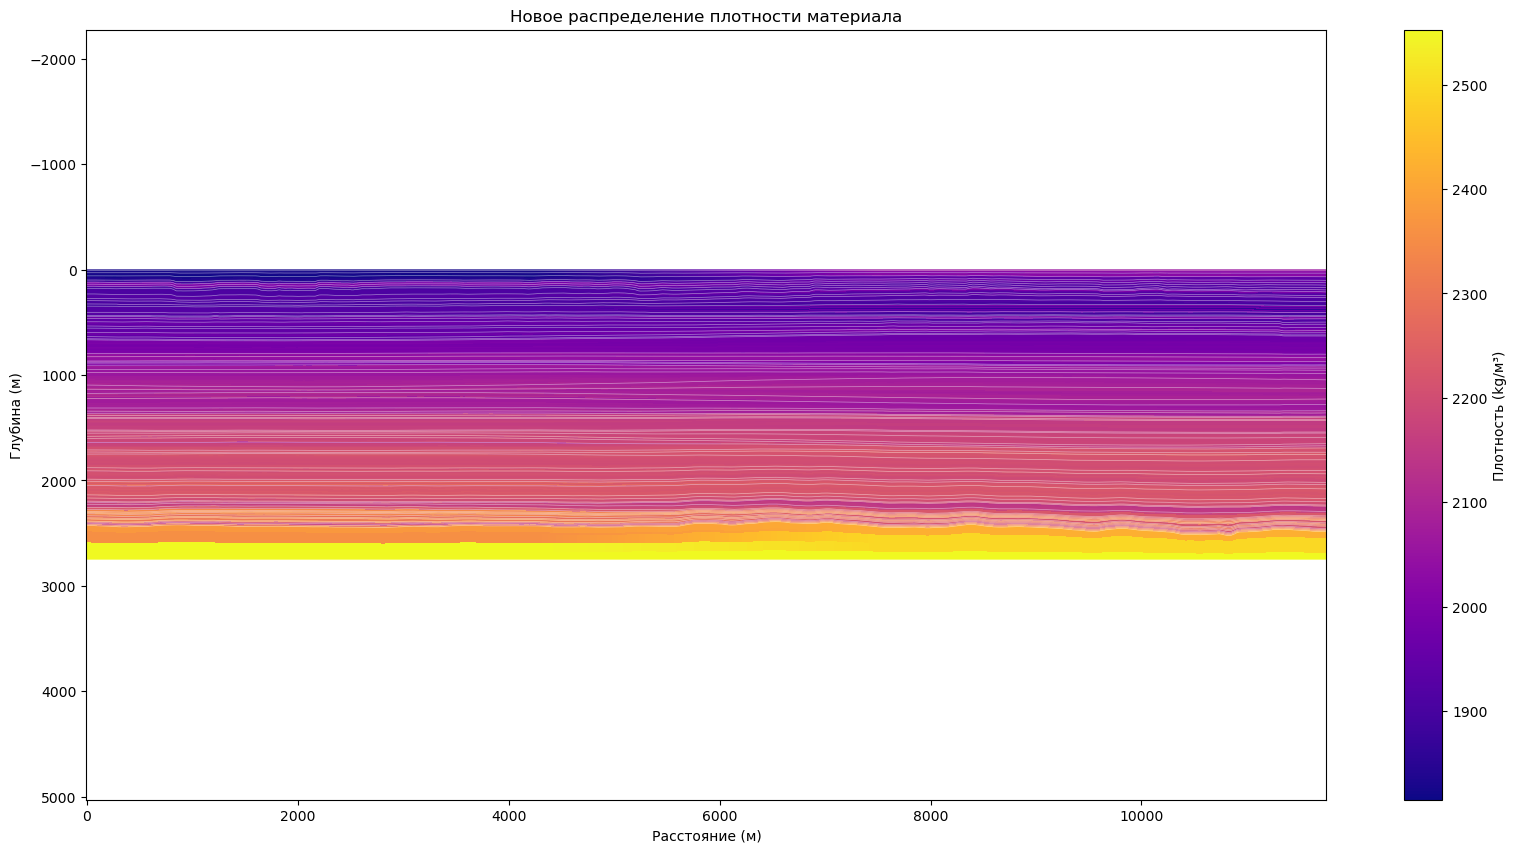

In [30]:
fig, ax = plt.subplots(figsize=(20, 10))
x = eulerian_coords[:, :, 0]
y = eulerian_coords[:, :, 1]
prop_to_plot = eulerian_props_nodes[:, :, 2]

quadmesh = ax.pcolormesh(x, y, prop_to_plot, cmap='plasma', shading='auto')
plt.colorbar(quadmesh, ax=ax, label='Плотность (kg/м³)')

for i in range(all_boundaries.shape[0]):
    ax.plot(distances, all_boundaries[i, :], color='white', lw=0.5, alpha=0.5)

ax.set_title('Новое распределение плотности материала')
ax.set_xlabel('Расстояние (м)')
ax.set_ylabel('Глубина (м)')
ax.invert_yaxis()
ax.axis('equal')

output_image_path = 'img/dev_1_6_new_material_density.png'
plt.savefig(output_image_path, dpi=300, bbox_inches='tight')
print(f"Визуализация сохранена в {output_image_path}")
if SHOW_PLOTS:
    plt.show()
else:
    plt.close()

In [31]:
(np.min(eulerian_props_nodes[:,:,0]), np.max(eulerian_props_nodes[:,:,0]),
np.min(eulerian_props_nodes[:,:,1]), np.max(eulerian_props_nodes[:,:,1]),
np.min(eulerian_props_nodes[:,:,2]), np.max(eulerian_props_nodes[:,:,2]))

(2072138485.797246,
 52327093765.94568,
 0.2833423225368595,
 0.2839499093069614,
 1814.8867,
 2552.687471)

#### 7. Разделение данных на слои ####

In [32]:
# Список для хранения данных по слоям
layered_material_data = []

# Текущий индекс элемента по вертикали
current_elem_idx = 0

for layer_idx in range(len(formations)):
    n_elements_in_layer = layer_elements_count[layer_idx]

    # Координаты центров элементов для слоя
    layer_coords = []
    layer_properties = []

    for i in range(n_xi_nodes):

        if layer_idx > 0:
            k = current_elem_idx - 2
            layer_coords.append(eulerian_coords[i, k, :])
            layer_properties.append(eulerian_props_nodes[i, k, :])

        for k in range(current_elem_idx, current_elem_idx + n_elements_in_layer+1):
            layer_coords.append(eulerian_coords[i, k, :])
            layer_properties.append(eulerian_props_nodes[i, k, :])

        if layer_idx < len(formations)-1:
            k = current_elem_idx + n_elements_in_layer + 2
            layer_coords.append(eulerian_coords[i, k, :])
            layer_properties.append(eulerian_props_nodes[i, k, :])

    # Переходим к следующему слою
    current_elem_idx += n_elements_in_layer+1

    # Преобразуем в numpy массивы
    layer_coords = np.array(layer_coords)
    layer_properties = np.array(layer_properties)

    # Создаем структуру для слоя
    layer_data = {
        'formations': formations[layer_idx],
        'coords': layer_coords,
        'properties': layer_properties
    }

    layered_material_data.append(layer_data)

    # print(f"Слой {layer_idx+1}: {formations[layer_idx]}, узлов материала: {len(layer_coords)}")

print(f"\nВсего создано {len(layered_material_data)} слоев материала")

# Сохраняем разделенные по слоям данные
layered_output_path = 'data/dev_1_6_layered_material.npz'
np.savez_compressed(layered_output_path,
                    layered_data=layered_material_data,
                    formations=formations)
print(f"Разделенные по слоям данные сохранены в {layered_output_path}")



Всего создано 75 слоев материала
Разделенные по слоям данные сохранены в data/dev_1_6_layered_material.npz


Можно создать материал вот так, но jou-файл получится гигантских размеров (~100 Mb), а за наблюдением процесса загрузки его в fidesys можно состариться. Поэтому мы создадим заглушку материала - частично записанный вариант, который потом дозаполним прямым редактированием fc.

Применим этот скрипт к созданному на шаге 1.5 файлу fds, после чего пересохраним последний в fc

In [40]:
row_limit = 2

with open('data/dev_1_6_model_material_stub.jou', 'w') as f:
    f.write(f'delete table all\n')
    f.write(f'delete block all\n')
    f.write(f'delete material all\n')
    f.write(f'set duplicate block elements on\n')

    i = 0

    for layer in layered_material_data:

        i += 1
    
        for l in range(3):
            f.write(f'block {i} add surface {3*i-l}\n')

        for k in range(4):
            f.write(f'create table {4*i-k} column count 3\n')
            f.write(f'modify table {4*i-k} dependency x column 1\n')
            f.write(f'modify table {4*i-k} dependency y column 2\n')

        for j in range(min(layer["coords"].shape[0], row_limit)):
            x = layer["coords"][j][0]
            y = layer["coords"][j][1]

            for k in range(3):
                f.write(f'modify table {4*i-k} insert row {j+1}\n')
                f.write(f'modify table {4*i-k} cell {j+1} 1 value {x}\n')
                f.write(f'modify table {4*i-k} cell {j+1} 2 value {y}\n')
                f.write(f'modify table {4*i-k} cell {j+1} 3 value {layer["properties"][j][k]}\n')


            mass_matrix_dampling = 0


            f.write(f'modify table {4*i-3} insert row {j+1}\n')

            f.write(f'modify table {4*i-3} cell {j+1} 1 value {layer["coords"][j][0]}\n')
            f.write(f'modify table {4*i-3} cell {j+1} 2 value {layer["coords"][j][1]}\n')
            f.write(f'modify table {4*i-3} cell {j+1} 3 value {mass_matrix_dampling}\n')


        f.write(f'create material {i}\n')
        f.write(f'modify material {i} name \'{layer['formations']} {i}\' \n')

        f.write(f'modify material {i} set property \'MODULUS\' table {4*i}\n')
        f.write(f'modify material {i} set property \'POISSON\' table {4*i-1}\n')
        f.write(f'modify material {i} set property \'DENSITY\' table {4*i-2}\n')
        f.write(f'modify material {i} set property \'MASS_MATRIX_DAMPING\' table {4*i-3}\n')

        f.write(f'modify material {i} set property \'BIOT_ALPHA\' value 1\n')

        f.write(f'block {i} material {i} cs 1 category plane order 4\n')


In [34]:
from fc_model import FCModel, FCMaterial, FCBlock, FCMaterialProperty, FCData, FCElement

In [35]:
fc_model = FCModel('/home/antonov/MilenSem2D/data/dev_1_6_model_material_stub.fc')

In [36]:
fc_model.materials[1].properties['elasticity'][0][1].data.table[0].value.data # x коордс
fc_model.materials[1].properties['elasticity'][0][1].data.table[1].value.data # y коордс

array([0.        , 4.95758048])

In [37]:
i = 0

for layer in layered_material_data:

    i += 1
    fc_model.materials[i].properties['elasticity'][0][0].data.table[0].value.data  = layer["coords"][:, 0]
    fc_model.materials[i].properties['elasticity'][0][0].data.table[1].value.data  = layer["coords"][:, 1]
    fc_model.materials[i].properties['elasticity'][0][0].data.value.data = layer["properties"][:, 0]

    fc_model.materials[i].properties['elasticity'][0][1].data.table[0].value.data  = layer["coords"][:, 0]
    fc_model.materials[i].properties['elasticity'][0][1].data.table[1].value.data  = layer["coords"][:, 1]
    fc_model.materials[i].properties['elasticity'][0][1].data.value.data = layer["properties"][:, 1]

    fc_model.materials[i].properties['common'][0][0].data.table[0].value.data  = layer["coords"][:, 0]
    fc_model.materials[i].properties['common'][0][0].data.table[1].value.data  = layer["coords"][:, 1]
    fc_model.materials[i].properties['common'][0][0].data.value.data = layer["properties"][:, 2]

    mass_matrix_dampling = np.zeros_like(layer["properties"][:, 1])

    for j in range(len(mass_matrix_dampling)):

        x = layer["coords"][:, 0][j]
        y = layer["coords"][:, 1][j]

        if x < 250 or x > 11500 or y > 2450:
            mass_matrix_dampling_x = 0
            mass_matrix_dampling_y = 0

            if x < 250:
                mass_matrix_dampling_x = 100*((250-x)/250)**2
            elif x > 11500:
                mass_matrix_dampling_x = 100*((x-11500)/250)**2

            if y > 2450:
                mass_matrix_dampling_y = 100*((y-2450)/350)**2

            mass_matrix_dampling[j] = max(mass_matrix_dampling_x, mass_matrix_dampling_y)


    fc_model.materials[i].properties['common'][0][1].data.table[0].value.data  = layer["coords"][:, 0]
    fc_model.materials[i].properties['common'][0][1].data.table[1].value.data  = layer["coords"][:, 1]
    fc_model.materials[i].properties['common'][0][1].data.value.data = mass_matrix_dampling

In [38]:
fc_model.save('/home/antonov/MilenSem2D/data/dev_1_6_model_material_full.fc')

In [39]:
with open('data/dev_1_6_material_simple.jou', 'w') as f:
    i = 0

    for layer in layered_material_data:

        i += 1

        E = np.mean(layer["properties"][:, 0])
        nu = np.mean(layer["properties"][:, 1])
        rho = np.mean(layer["properties"][:, 2])

        f.write(f"modify material {i} set property 'MODULUS' value {E}\n")
        f.write(f"modify material {i} set property 'POISSON' value {nu}\n")
        f.write(f"modify material {i} set property 'DENSITY' value {rho}\n")
        f.write(f"modify material {i} set property 'MASS_MATRIX_DAMPING' value 0\n")



Код для тестового расчета в Fidesys

create porepressure on node 207
create formula 1 'ricker(1e+07, 30, 0, time)'
modify porepressure 1 formula 1
block all order 2
analysis type dynamic elasticity dim2 planestrain preload off
dynamic method full_solution scheme explicit maxsteps 10000 maxtime 1
dynamic results everytime 0.1
output nodalforce off energy off record3d off material on without_smoothing off fullperiodic off